## Run the analysis on a single field of view 
Use
- stored configuration file
- stored filelist


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import cellpose 
print(cellpose.version)

4.0.8


/cephfs2/jeromeb/userdata/Bullock_group/Eve Methab/260922_kinase-assembly/30 min as 2 2.lsm 0
Processing [SG]
  pixel size [1e-10, 346.6254340277775, 346.6254340277775]
Segmenting images 
   image shape (1024, 1024)
 - Segmenting cells with mode 0
    Cell size 144
    Image shape (2, 1024, 1024)


pretrained model /lmb/home/jeromeb/.cellpose/models/cpsam not found, using default model


 - Segmenting nuclei with diamter 16.5um / 47.60181562059794px
 - Segmenting granule
 - Segmenting granule
 - Compute ROI statistics


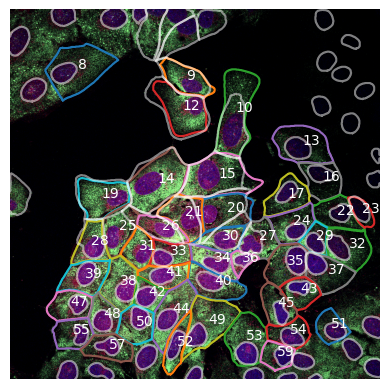

In [3]:
import sganalysiswf as sga
from pathlib import Path
import pandas as pd

data_path = Path("/cephfs/emehtab/SG diassesmbly work/260922_kinase assembly screen/lsm/260922 kinase assembly for analysis")
data_path = Path("/cephfs2/jeromeb/userdata/Bullock_group/Eve Methab/260922_kinase-assembly")
filelist = pd.read_csv(data_path / "filelist.csv")
configfile = data_path / "config.json"

config = sga.load_config(configfile)
# # config = {'Analysis': 'SG', 'channels': [{'index': 2, 'name': 'nuclei'}, {'index': 0, 'name': 'membrane'}, {'index': 0, 'name': 'granule'}, {'index': 1, 'name': 'other'}], 'NA': 0.95, 'medium_refractive_index': 1.4, 'scale_um': 50, 'mode': 0}
# config = {
#     "Analysis": "SG",
#     "channels": [
#         {"index": 2, "name": "nuclei"},
#         {"index": 3, "name": "membrane"},
#         {"index": 0, "name": "granule"},
#         {"index": 1, "name": "other"},
#     ],
#     "NA": 0.95,
#     "medium_refractive_index": 1.4,
#     "scale_um": 35,
#     "mode": 0,
# }
idx = 0
filename = data_path / filelist["filename"][idx]
fov = filelist["fov"][idx]
print(filename, fov)
stats, mip, labels, rois = sga.process_fov(filename, fov, config)
sga.show_image(mip, labels, rois, stats)

In [13]:
mip["nuclei"].shape

(1024, 1024)

pretrained model /lmb/home/jeromeb/.cellpose/models/cpsam not found, using default model


 - Segmenting nuclei with diamter 16.50um / 47.69px


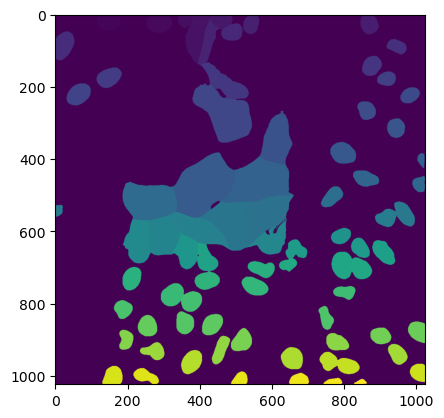

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(mip["nuclei"])

mask = sga.segment_nuclei(mip["nuclei"], [500,346,346], 50)
plt.imshow(mask+mip["nuclei"])

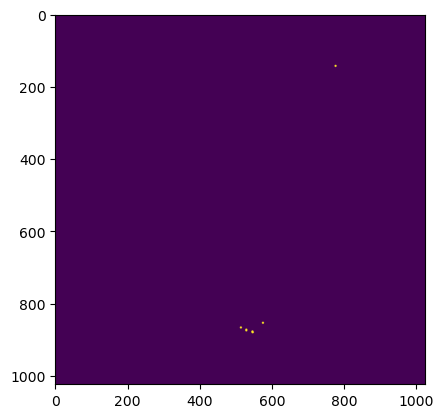

In [56]:
import matplotlib.pyplot as plt
plt.imshow((labels['granule']>0).astype(float) + mip["granule"].astype(float)/mip["granule"].max())
plt.imshow((labels['granule']>0).astype(float))

 - Segmenting granule


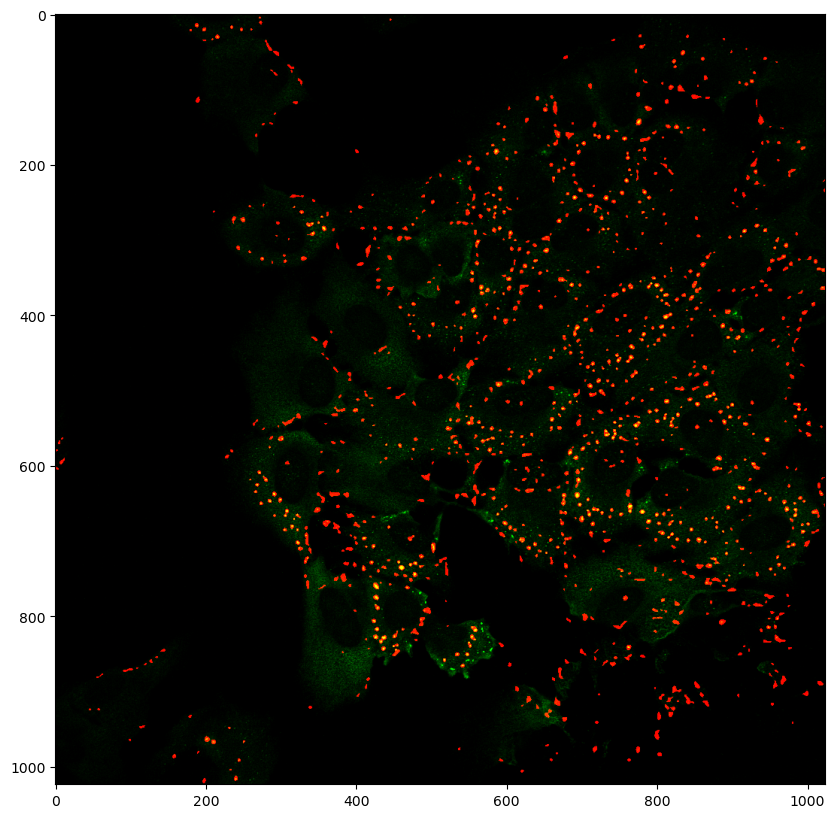

In [185]:
import numpy as np
from skimage import morphology
from skimage import filters
from scipy import ndimage as ndi
mask = sga.segment_granules(mip['granule'])
rgb = np.zeros((mask.shape[0],mask.shape[1],3))
rgb[:,:,0] = mask>0
rgb[:,:,1] = mip["granule"].astype(float)/mip["granule"].max()
plt.figure(figsize=(10,10))
plt.imshow(rgb)


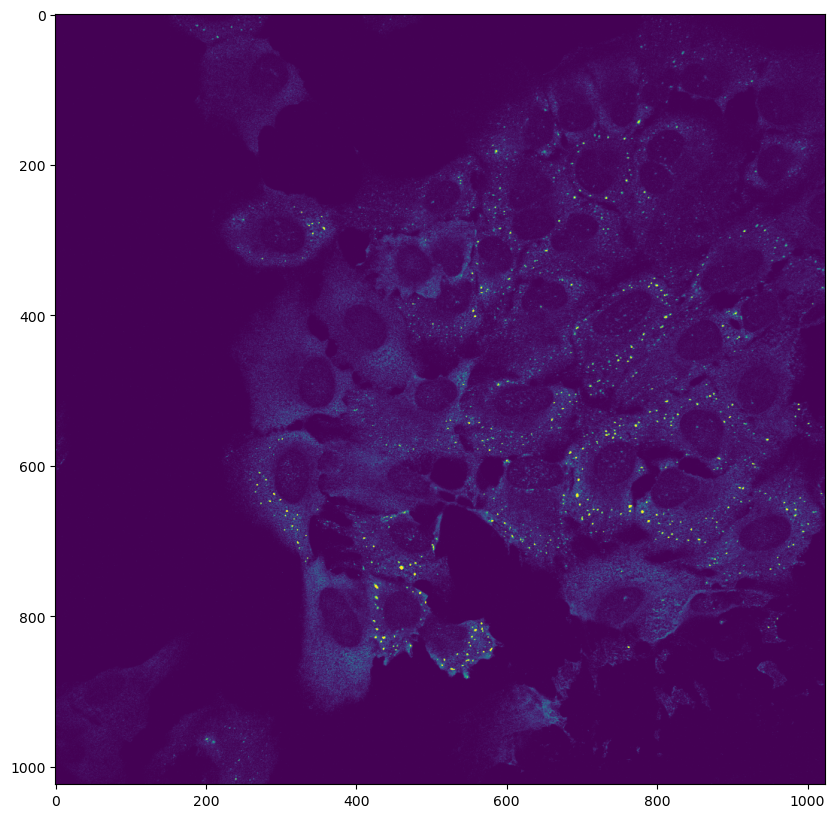

In [137]:
plt.figure(figsize=(10,10))
plt.imshow(img)

In [ ]:
# export for training
import sganalysiswf as sga
from pathlib import Path
import pandas as pd
import tifffile

data_path = Path("/media/cephfs2/jeromeb/userdata/Bullock_group/Eve Methab")
filelist = pd.read_csv(data_path / "filelist.csv")
configfile = data_path / "config.json"
config = sga.load_config(configfile)
dest = Path("/home/jeromeb/Desktop/export")
dest.mkdir(exist_ok=True)
for k,row in enumerate(filelist.iloc):
    filename = data_path / row["filename"]
    data, pixel_size = sga.load_image(filename, row["fov"])
    tifffile.imwrite(dest/f"{k}.tif", data[[0,2,3]])
    